In [2]:
pip install geopandas

   ---------------------------------------- 0.0/22.9 MB ? eta -:--:--
    --------------------------------------- 0.5/22.9 MB 5.3 MB/s eta 0:00:05
   - -------------------------------------- 0.8/22.9 MB 2.4 MB/s eta 0:00:10
   - -------------------------------------- 0.8/22.9 MB 2.4 MB/s eta 0:00:10
   - -------------------------------------- 1.0/22.9 MB 1.3 MB/s eta 0:00:17
   -- ------------------------------------- 1.3/22.9 MB 1.1 MB/s eta 0:00:21
   -- ------------------------------------- 1.3/22.9 MB 1.1 MB/s eta 0:00:21
   -- ------------------------------------- 1.3/22.9 MB 1.1 MB/s eta 0:00:21
   -- ------------------------------------- 1.6/22.9 MB 914.9 kB/s eta 0:00:24
   -- ------------------------------------- 1.6/22.9 MB 914.9 kB/s eta 0:00:24
   --- ------------------------------------ 1.8/22.9 MB 818.6 kB/s eta 0:00:26
   --- ------------------------------------ 1.8/22.9 MB 818.6 kB/s eta 0:00:26
   --- ------------------------------------ 1.8/22.9 MB 818.6 kB/s eta 0:00

In [3]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("Metro_zhvi_uc_sfrcondo_tier_0.33_0.67_sm_sa_month.csv")

In [6]:
geo = gpd.read_file("cb_2018_us_cbsa_500k.shp")

In [9]:
df_long = df.melt(
    id_vars=["RegionID", "RegionName", "StateName"],
    var_name="Date",
    value_name="Price"
)

df_long["Date"] = pd.to_datetime(df_long["Date"], errors = 'coerce')

C:\Users\Janvi Sanghavi\AppData\Local\Temp\ipykernel_16892\2345418594.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_long["Date"] = pd.to_datetime(df_long["Date"], errors = 'coerce')


In [10]:
df_long = df_long.dropna(subset = ['Date'])

In [11]:
df_long.head()

,RegionID,RegionName,StateName,Date,Price
1790,102001,United States,NaN,2000-01-31,121066.152956
1791,394913,"New York, NY",NY,2000-01-31,216280.79661
1792,753899,"Los Angeles, CA",CA,2000-01-31,221540.469091
1793,394463,"Chicago, IL",IL,2000-01-31,151333.694136
1794,394514,"Dallas, TX",TX,2000-01-31,128246.740882


In [12]:
df_2023 = df_long[df_long["Date"].dt.year == 2023]

df_avg = df_2023.groupby("RegionName")["Price"].mean().reset_index()

In [13]:
df_avg["RegionName"] = df_avg["RegionName"].str.strip()
geo["NAME"] = geo["NAME"].str.strip()

In [14]:
merged = geo.merge(
    df_avg,
    left_on = "NAME",
    right_on = "RegionName"
)

In [15]:
print(merged.shape)

(695, 11)


In [20]:
pip install mapclassify

   ---------------------------------------- 0.0/882.2 kB ? eta -:--:--
   ----------------------- ---------------- 524.3/882.2 kB 2.6 MB/s eta 0:00:01
   ---------------------------------------- 882.2/882.2 kB 2.7 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


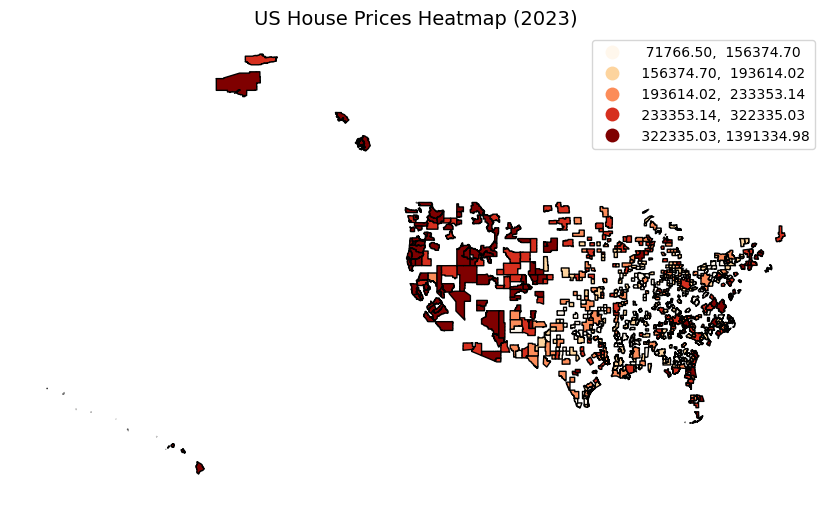

In [21]:
merged.plot(
    column = "Price",
    cmap = "OrRd",
    legend = "True",
    scheme = "quantiles",
    k = 5,
    figsize = (12, 6),
    edgecolor = "black"
)

plt.title("US House Prices Heatmap (2023)", fontsize = 14)
plt.axis("off")
plt.show()

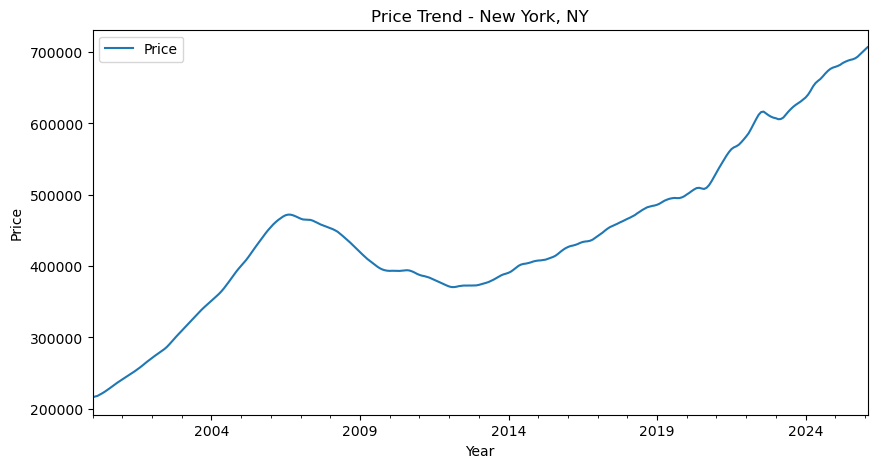

In [24]:
city = "New York, NY"

df_city = df_long[df_long["RegionName"] == city]
df_city.plot(x = "Date", y = "Price", figsize = (10, 5))
plt.title(f"Price Trend - {city}")
plt.xlabel("Year")
plt.ylabel("Price")
plt.show()

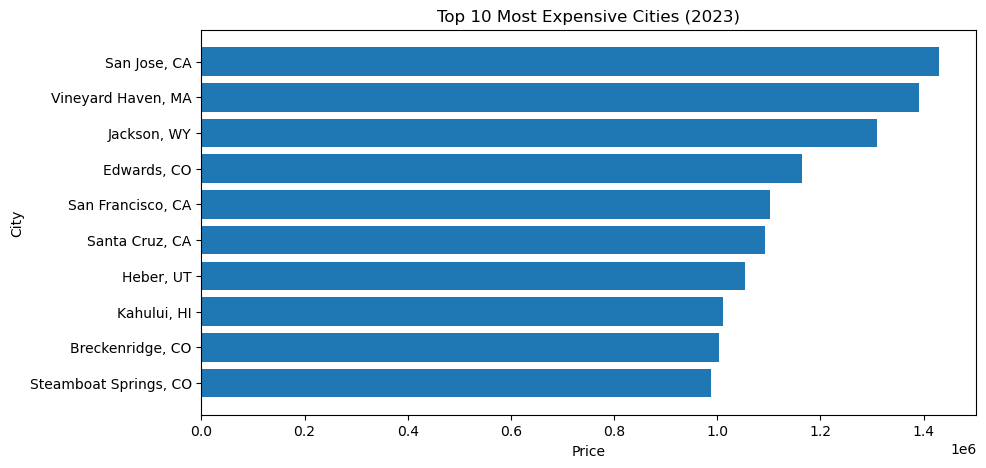

In [25]:
top10 = df_avg.sort_values(by = "Price", ascending = False).head(10)

plt.figure(figsize = (10, 5))
plt.barh(top10["RegionName"], top10["Price"])
plt.title("Top 10 Most Expensive Cities (2023)")
plt.xlabel("Price")
plt.ylabel("City")
plt.gca().invert_yaxis()

plt.show()

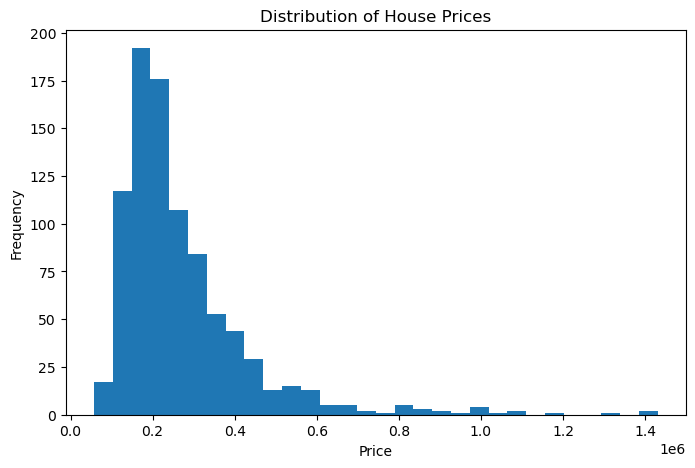

In [26]:
plt.figure(figsize = (8, 5))
plt.hist(df_avg["Price"], bins = 30)
plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()